In [190]:
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Number of points to eliminate due to high attenuation 

In [191]:
path_to_fit_parameters  = "/media/matheustolen/Seagate Basic/cloudnet/cloud_classification/fit_parameters"

# List all files in the directory follwing the pattern:
pattern = "*count_verification.nc"
files   = glob.glob(os.path.join(path_to_fit_parameters, pattern))

# Read the files and concatenate in time dimension
ds_fit = xr.open_mfdataset(files, combine='by_coords')

In [192]:
# New variable: Sum of count_high_lwp and count_in_between_lwp
ds_fit['count_high_lwp_in_between'] = ds_fit.count_high_lwp + ds_fit.count_in_between_lwp

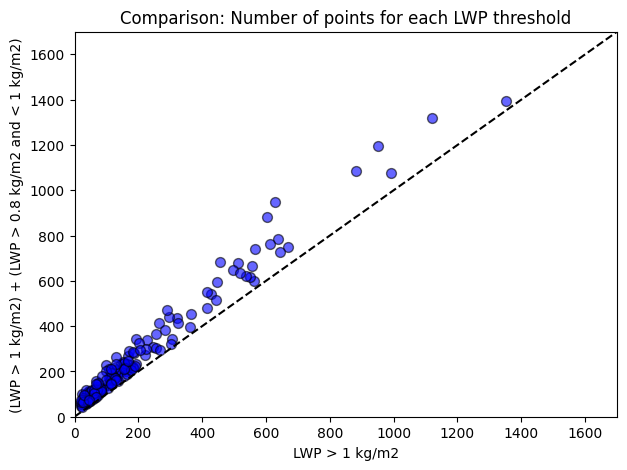

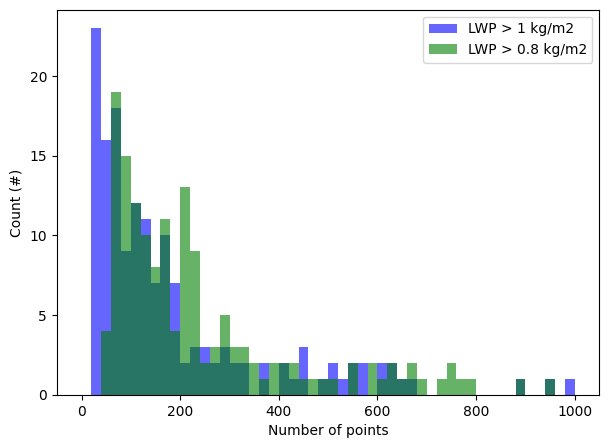

In [193]:
xmax = 1700
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# ds_fit.count_high_lwp.plot(ax=ax, color='blue', label='LWP > 1 kg/m2')
# ds_fit.count_high_lwp_in_between.plot(ax=ax, color='red', label='(LWP > 1 kg/m2) + (LWP > 0.8 kg/m2 and < 1 kg/m2)')
ax.scatter(ds_fit.count_high_lwp, ds_fit.count_high_lwp_in_between, color='blue', s=50, marker='o', edgecolors='black', alpha=0.6)
ax.set_title('Comparison: Number of points for each LWP threshold')
# plot the line of equality
ax.plot([0, xmax], [0, xmax], color='black', linestyle='--')
ax.set_xlabel('LWP > 1 kg/m2')
ax.set_ylabel('(LWP > 1 kg/m2) + (LWP > 0.8 kg/m2 and < 1 kg/m2)')
ax.set_xlim([0, xmax])
ax.set_ylim([0, xmax])
# ax.legend()
plt.show()

# Plot two histograms of the slope parameters. For slope_larger and slope_small:
bin_width = 20
bins = np.arange(0, 1000 + bin_width, bin_width)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ds_fit.count_high_lwp.plot.hist(ax=ax, bins=bins, color='blue', alpha=0.6, label='LWP > 1 kg/m2')
ds_fit.count_high_lwp_in_between.plot.hist(ax=ax, bins=bins, color='green', alpha=0.6, label='LWP > 0.8 kg/m2')
ax.set_xlabel('Number of points')
ax.set_ylabel('Count (#)')
ax.legend()
plt.show()

## Fit parameters from Radar LWP x MWR LWP

In [170]:
path_to_fit_parameters  = "/media/matheustolen/Seagate Basic/cloudnet/cloud_classification/fit_parameters"

# List all files in the directory follwing the pattern:
pattern = "*_fit_params.nc"
files   = glob.glob(os.path.join(path_to_fit_parameters, pattern))

# Read the files and concatenate in time dimension
ds_fit = xr.open_mfdataset(files, combine='by_coords')

          date  slope_larger  slope_small
0   2018-09-14      0.848632     0.978548
1   2018-09-15      0.686210     1.104398
2   2018-09-17      0.690657     0.995563
3   2018-09-19      0.572378     1.173797
4   2018-09-26      0.599649     0.982985
..         ...           ...          ...
139 2023-12-01      0.573884     0.734920
140 2023-12-04      0.286154     0.822645
141 2023-12-05     -0.092554     0.612997
142 2023-12-06     -0.011664     0.882575
143 2023-12-13      0.821914     0.500571

[144 rows x 3 columns]


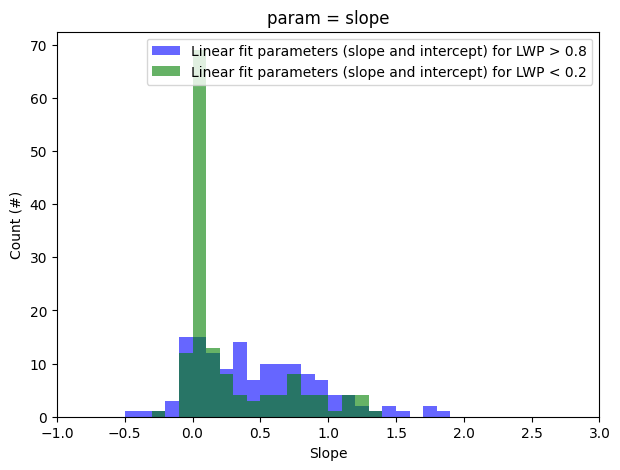

In [174]:
# print only the slope parameters and their dates, side by side
print( pd.DataFrame({'date': ds_fit.date.values, 'slope_larger': ds_fit.params_larger.sel(param='slope').values, 'slope_small': ds_fit.params_small.sel(param='slope').values}) ) 

# Plot two histograms of the slope parameters. For slope_larger and slope_small:
bin_width = 0.1
bins = np.arange(-5, 5 + bin_width, bin_width)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ds_fit.params_larger.sel(param='slope').plot.hist(ax=ax, bins=bins, color='blue', alpha=0.6, label=ds_fit.params_larger.attrs['description'])
ds_fit.params_small.sel(param='slope').plot.hist(ax=ax, bins=bins, color='green', alpha=0.6, label=ds_fit.params_small.attrs['description'])
ax.set_xlabel('Slope')
ax.set_ylabel('Count (#)')
ax.set_xlim(-1, 3)
ax.legend()
plt.show()

          date  intercept_larger  intercept_small
0   2018-09-14          0.329686         0.018588
1   2018-09-15          0.711984         0.026550
2   2018-09-17          0.814356         0.001972
3   2018-09-19          0.855803         0.006199
4   2018-09-26          0.820692         0.010859
..         ...               ...              ...
139 2023-12-01          0.478406        -0.006516
140 2023-12-04          0.768286        -0.005191
141 2023-12-05          1.280219        -0.000105
142 2023-12-06          1.007760         0.004063
143 2023-12-13          0.227154         0.004247

[144 rows x 3 columns]


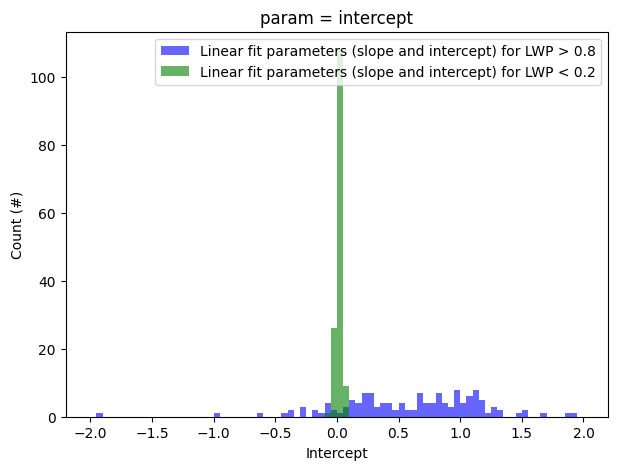

In [189]:
# print only the intercept parameters and their dates, side by side
print( pd.DataFrame({'date': ds_fit.date.values, 'intercept_larger': ds_fit.params_larger.sel(param='intercept').values, 'intercept_small': ds_fit.params_small.sel(param='intercept').values}) )

# Plot two histograms of the intercept parameters. For intercept_larger and intercept_small:
bin_width = .05
bins = np.arange(-2, 2 + bin_width, bin_width)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ds_fit.params_larger.sel(param='intercept').plot.hist(ax=ax, bins=bins, color='blue', alpha=0.6, label=ds_fit.params_larger.attrs['description'])   
ds_fit.params_small.sel(param='intercept').plot.hist(ax=ax, bins=bins, color='green', alpha=0.6, label=ds_fit.params_small.attrs['description'])
ax.set_xlabel('Intercept')
ax.set_ylabel('Count (#)')
ax.legend()
plt.show()

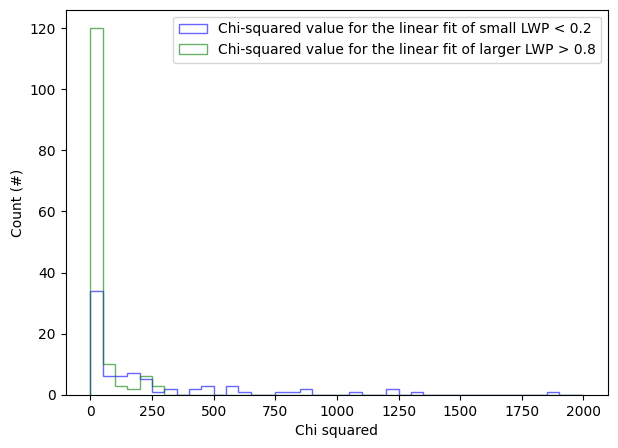

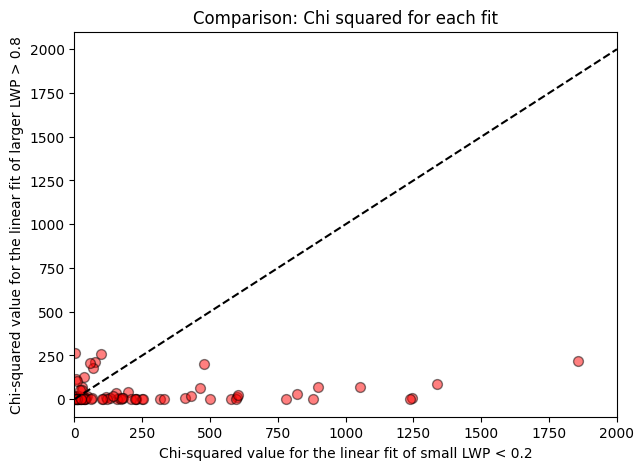

In [187]:
# print the histogram of chi squared

bin_width = 50
bins = np.arange(0, 2000 + bin_width, bin_width)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ds_fit.chi2_small.plot.hist(ax=ax, bins=bins, color='blue', alpha=0.6, label=ds_fit.chi2_small.attrs['description'], histtype='step')
ds_fit.chi2_larger.plot.hist(ax=ax, bins=bins, color='green', alpha=0.6, label=ds_fit.chi2_larger.attrs['description'], histtype='step')
ax.set_xlabel('Chi squared')
ax.set_ylabel('Count (#)')
ax.legend()
plt.show()

# make a scatter plot of chi2_small and chi2_larger
xmax = 2000
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(ds_fit.chi2_small, ds_fit.chi2_larger, color='red', s=50, marker='o', edgecolors='black', alpha=0.5)
ax.set_title('Comparison: Chi squared for each fit')
# plot the line of equality
ax.plot([0, xmax], [0, xmax], color='black', linestyle='--')
ax.set_xlabel(ds_fit.chi2_small.attrs['description'])
ax.set_ylabel(ds_fit.chi2_larger.attrs['description'])
ax.set_xlim([0, xmax])
plt.show()
